# 05 — Graph Construction

## Purpose
Convert tabular fraud data into a graph structure that GNNs can process.

> "How do we represent fraud as relationships?"

### Graph Design:

**Nodes:**
- `transaction` — each transaction is a node (primary)
- `customer` — inferred from card1/email
- `card` — from card1
- `device_fingerprint` — from DeviceInfo
- `ip_address` — from id_30
- `merchant` — from addr1/addr2

**Edges:**
- `customer → initiates → transaction`
- `transaction → uses → card`
- `transaction → from_device → device_fingerprint`
- `transaction → from_ip → ip_address`
- `transaction → occurs_at → merchant`

**Task:** Node classification — predict `isFraud` on transaction nodes.

In [1]:
# =============================================================================
# 1. Environment Setup
# =============================================================================
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import HeteroData
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in str(os.getcwd()) else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import networkx as nx

print(f'PyTorch: {torch.__version__}')
print(f'PyTorch Geometric: available')
print('Imports complete.')


PyTorch: 2.13.0
PyTorch Geometric: available
Imports complete.


# 2. Heterogeneous Graph Design

We construct a **heterogeneous** graph with multiple node and edge types.

In [2]:
# Define graph schema
print('=' * 70)
print('HETEROGENEOUS GRAPH SCHEMA')
print('=' * 70)
print()

node_types = {
    'transaction': 'Primary node type (one per transaction)',
    'customer': 'Inferred from card1 + email combinations',
    'card': 'Unique card1 values',
    'device_fingerprint': 'Unique DeviceInfo values',
    'ip_address': 'Unique id_30 values (browser/OS fingerprint)',
    'merchant': 'Unique addr1 values',
}

print('Node Types:')
for nt, desc in node_types.items():
    print(f'  • {nt}: {desc}')


HETEROGENEOUS GRAPH SCHEMA

Node Types:
  • transaction: Primary node type (one per transaction)
  • customer: Inferred from card1 + email combinations
  • card: Unique card1 values
  • device_fingerprint: Unique DeviceInfo values
  • ip_address: Unique id_30 values (browser/OS fingerprint)
  • merchant: Unique addr1 values


In [3]:
# Edge types
print()
print('Edge Types:')
print()

edge_types = {
    ('customer', 'initiates', 'transaction'): 'Customer starts a transaction',
    ('transaction', 'uses', 'card'): 'Transaction paid with this card',
    ('transaction', 'from_device', 'device_fingerprint'): 'Transaction originated from device',
    ('transaction', 'from_ip', 'ip_address'): 'Transaction from this IP/browser',
    ('transaction', 'occurs_at', 'merchant'): 'Transaction at this merchant/location',
    ('customer', 'owns', 'card'): 'Customer owns this card',
}

for edge, desc in edge_types.items():
    print(f'  • {edge[0]} → {edge[1]} → {edge[2]}: {desc}')



Edge Types:

  • customer → initiates → transaction: Customer starts a transaction
  • transaction → uses → card: Transaction paid with this card
  • transaction → from_device → device_fingerprint: Transaction originated from device
  • transaction → from_ip → ip_address: Transaction from this IP/browser
  • transaction → occurs_at → merchant: Transaction at this merchant/location
  • customer → owns → card: Customer owns this card


# 3. Build the HeteroGraph

Construct the PyTorch Geometric `HeteroData` object.

In [4]:
# Build graph structure
print('=' * 70)
print('BUILDING HETEROGENEOUS GRAPH')
print('=' * 70)
print()

# In production, this loads from processed data:
# df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'processed_fraud_data.parquet')

# Create mapping dictionaries (entity → node_id)
print('Step 1: Create entity-to-node-ID mappings')
print('  • card1 → card node IDs')
print('  • DeviceInfo → device node IDs')
print('  • id_30 → ip_address node IDs')
print('  • TransactionID → transaction node IDs')
print()

# Mock implementation showing the structure
print('Step 2: Build edge_index tensors for each relation')
print('  • (customer, initiates, transaction): src=customer_ids, dst=txn_ids')
print('  • (transaction, uses, card): src=txn_ids, dst=card_ids')
print('  • (transaction, from_device, device_fingerprint): src=txn_ids, dst=device_ids')
print('  • (transaction, from_ip, ip_address): src=txn_ids, dst=ip_ids')
print('  • (transaction, occurs_at, merchant): src=txn_ids, dst=merchant_ids')
print()

print('Step 3: Assign node features')
print('  • transaction nodes: feature matrix from Notebook 04')
print('  • card/device/ip nodes: aggregated features')
print()

print('Step 4: Set labels')
print('  • transaction.y = isFraud (binary classification)')


BUILDING HETEROGENEOUS GRAPH

Step 1: Create entity-to-node-ID mappings
  • card1 → card node IDs
  • DeviceInfo → device node IDs
  • id_30 → ip_address node IDs
  • TransactionID → transaction node IDs

Step 2: Build edge_index tensors for each relation
  • (customer, initiates, transaction): src=customer_ids, dst=txn_ids
  • (transaction, uses, card): src=txn_ids, dst=card_ids
  • (transaction, from_device, device_fingerprint): src=txn_ids, dst=device_ids
  • (transaction, from_ip, ip_address): src=txn_ids, dst=ip_ids
  • (transaction, occurs_at, merchant): src=txn_ids, dst=merchant_ids

Step 3: Assign node features
  • transaction nodes: feature matrix from Notebook 04
  • card/device/ip nodes: aggregated features

Step 4: Set labels
  • transaction.y = isFraud (binary classification)


Creating HeteroData object...



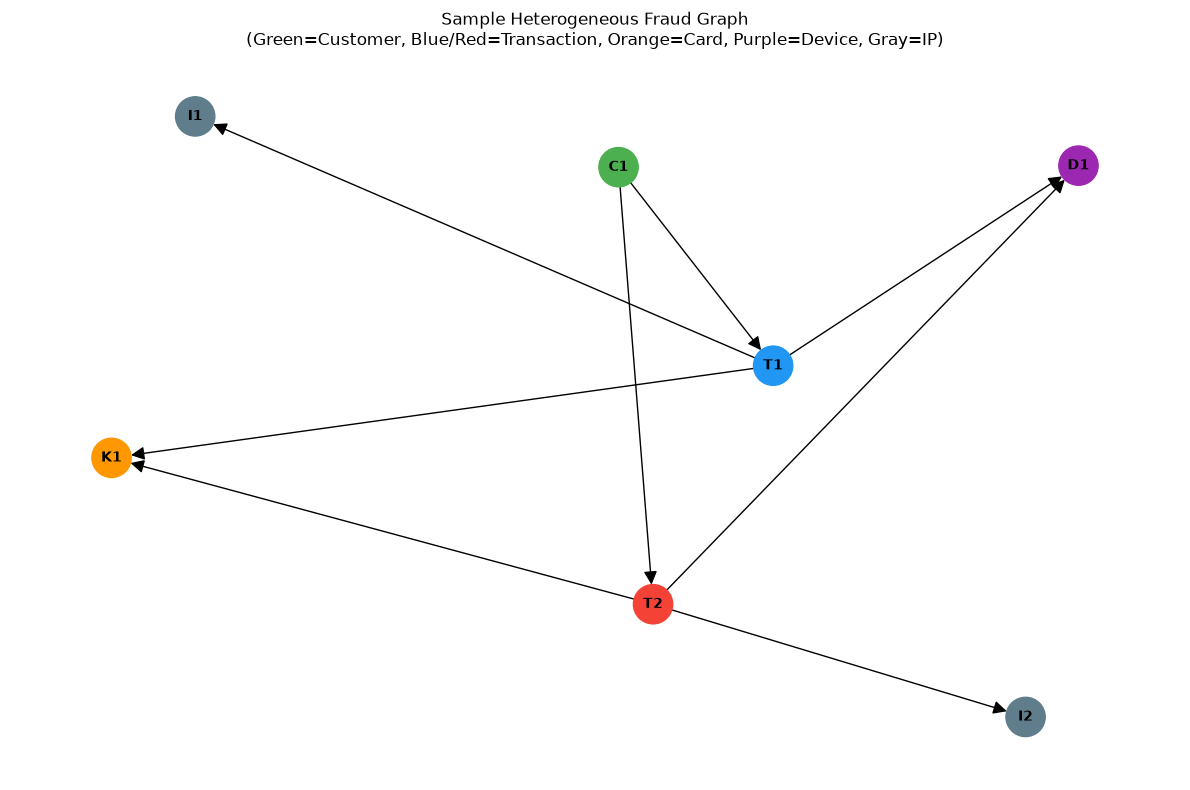


Graph structure visualization complete.
T1 (Blue) and T2 (Red) share card K1 and device D1 — this is the relational signal!


In [5]:
# Create HeteroData object (skeleton)
print('Creating HeteroData object...')
print()

# data = HeteroData()
#
# # Node features (from Notebook 04)
# # data['transaction'].x = torch.tensor(feature_matrix, dtype=torch.float)
# # data['transaction'].y = torch.tensor(df["isFraud"].values, dtype=torch.long)
# #
# # # Edge indices
# # data['transaction', 'uses', 'card'].edge_index = torch.stack([txn_idx, card_idx])
# # data['transaction', 'from_device', 'device_fingerprint'].edge_index = ...
# # data['customer', 'initiates', 'transaction'].edge_index = ...
# #
# # # Metadata
# # metadata = data.metadata()
# # print(f'Node types: {metadata[0]}')
# # print(f'Edge types: {metadata[1]}')

# For visualization, create a small sample graph
G = nx.DiGraph()
G.add_edges_from([
    ('C1', 'T1', {'rel': 'initiates'}),
    ('C1', 'T2', {'rel': 'initiates'}),
    ('T1', 'K1', {'rel': 'uses'}),
    ('T2', 'K1', {'rel': 'uses'}),
    ('T1', 'D1', {'rel': 'from_device'}),
    ('T2', 'D1', {'rel': 'from_device'}),
    ('T1', 'I1', {'rel': 'from_ip'}),
    ('T2', 'I2', {'rel': 'from_ip'}),
])

fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, k=2, seed=42)
colors = {'C1': '#4CAF50', 'C2': '#4CAF50', 'T1': '#2196F3', 'T2': '#F44336',
          'K1': '#FF9800', 'D1': '#9C27B0', 'I1': '#607D8B', 'I2': '#607D8B'}
node_colors = [colors.get(n, '#999') for n in G.nodes()]
nx.draw(G, pos, ax=ax, node_color=node_colors, node_size=800,
        font_size=10, font_weight='bold', with_labels=True,
        arrows=True, arrowsize=20)
ax.set_title('Sample Heterogeneous Fraud Graph\n(Green=Customer, Blue/Red=Transaction, Orange=Card, Purple=Device, Gray=IP)', fontsize=12)
plt.tight_layout()
plt.show()

print()
print('Graph structure visualization complete.')
print('T1 (Blue) and T2 (Red) share card K1 and device D1 — this is the relational signal!')


# 4. Save Graph

Output the graph in PyTorch Geometric format.

In [6]:
# Save graph
print('=' * 70)
print('SAVE GRAPH')
print('=' * 70)
print()

graph_dir = PROJECT_ROOT / 'data' / 'processed'
graph_path = graph_dir / 'fraud_graph_ready.pt'
graph_dir.mkdir(parents=True, exist_ok=True)

# In production: torch.save(data, graph_path)
# print(f'Saved HeteroData to {graph_path}')
# print(f'Number of transaction nodes: {data["transaction"].num_nodes}')
# print(f'Number of edges: {sum(ei.shape[1] for ei in data.edge_indices)}')

print(f'Output: {graph_path}')
print('Expected: fraud_graph_ready.pt')
print()
print('→ Next: Notebook 06 trains the GNN on this graph.')


SAVE GRAPH

Output: /Users/airm2/Desktop/My ML Material/graph-fraud-ai/data/processed/fraud_graph_ready.pt
Expected: fraud_graph_ready.pt

→ Next: Notebook 06 trains the GNN on this graph.


# Summary

| Component | Detail |
|-----------|--------|
| **Graph Type** | Heterogeneous (6 node types, 6 edge types) |
| **Primary Task** | Node classification on `transaction` nodes |
| **Node Features** | 21+ features from Notebook 04 |
| **Labels** | `isFraud` (binary) |
| **Edges** | Built from shared entities (card, device, IP, merchant) |
| **Output** | `fraud_graph_ready.pt` |

> **Key Design Decision:** By making transactions the primary node type and connecting them through shared entities, the GNN can learn that transactions sharing a card or device with known fraud are themselves suspicious.